Generating simulated data for analysis...
Simulated data generation complete.


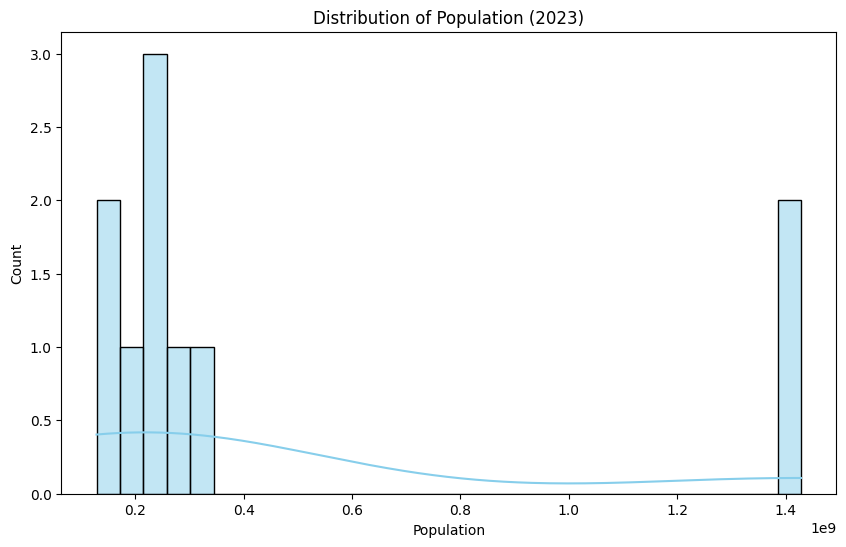

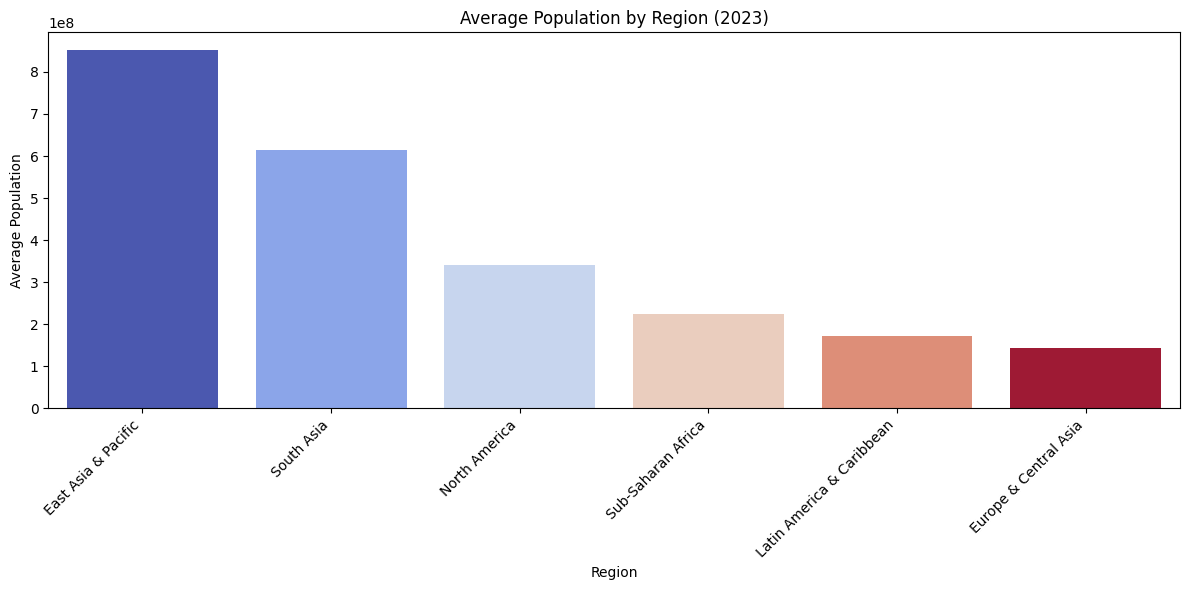

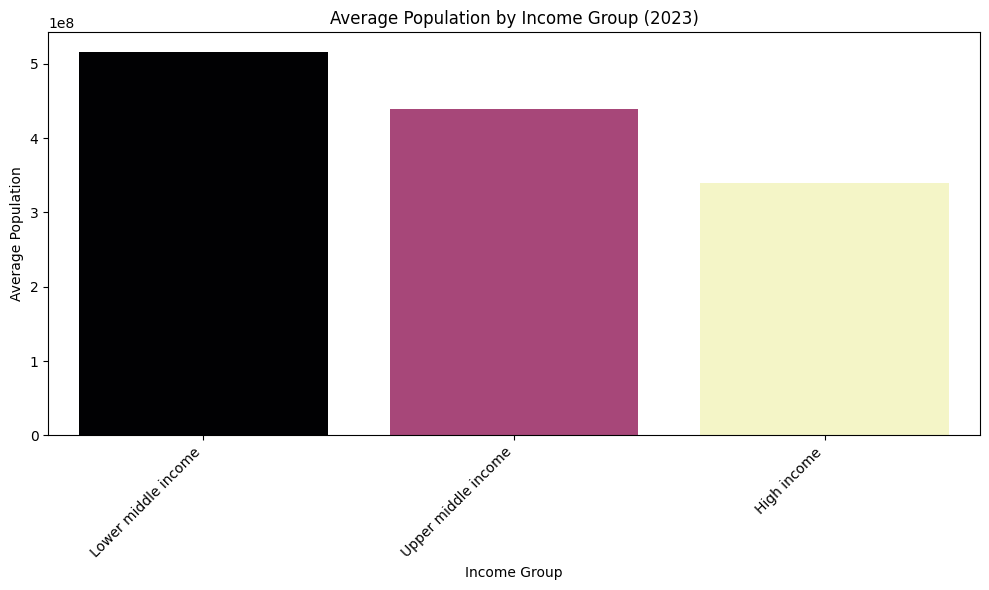

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

# --- Simulate data to run the analysis since files are not found ---
# NOTE: This data is for demonstration purposes only and is not real.

print("Generating simulated data for analysis...")

# Simulated population data
data_pop = {
    'Country Name': ['China', 'India', 'United States', 'Indonesia', 'Pakistan', 'Brazil', 'Nigeria', 'Bangladesh', 'Russia', 'Mexico', 'World', 'Europe & Central Asia'],
    'Country Code': ['CHN', 'IND', 'USA', 'IDN', 'PAK', 'BRA', 'NGA', 'BGD', 'RUS', 'MEX', 'WLD', 'ECS'],
    'Indicator Name': ['Population, total'] * 12,
    'Indicator Code': ['SP.POP.TOTL'] * 12,
    '2023': [1425671352, 1428627663, 339996563, 277534122, 240485658, 216422446, 223804632, 172954319, 144444359, 128455567, 8045311447, 924531144],
    '2022': [1425887337, 1417173173, 338289857, 275501339, 235824862, 215313498, 218541212, 171186372, 145000000, 127504125, 7975105156, 920105156],
}
df_pop = pd.DataFrame(data_pop)

# Simulated country metadata
data_country_meta = {
    'Country Code': ['CHN', 'IND', 'USA', 'IDN', 'PAK', 'BRA', 'NGA', 'BGD', 'RUS', 'MEX', 'WLD', 'ECS'],
    'Region': ['East Asia & Pacific', 'South Asia', 'North America', 'East Asia & Pacific', 'South Asia', 'Latin America & Caribbean', 'Sub-Saharan Africa', 'South Asia', 'Europe & Central Asia', 'Latin America & Caribbean', 'Aggregates', 'Aggregates'],
    'IncomeGroup': ['Upper middle income', 'Lower middle income', 'High income', 'Upper middle income', 'Lower middle income', 'Upper middle income', 'Lower middle income', 'Lower middle income', 'Upper middle income', 'Upper middle income', 'Aggregates', 'Aggregates'],
}
df_country_meta = pd.DataFrame(data_country_meta)

# Simulated indicator metadata
data_indicator_meta = {
    'INDICATOR_CODE': ['SP.POP.TOTL'],
    'Indicator Name': ['Population, total'],
}
df_indicator_meta = pd.DataFrame(data_indicator_meta)

print("Simulated data generation complete.")

# --- The following code is based on your original script ---

# Merge population with country metadata on 'Country Code'
df = pd.merge(df_pop, df_country_meta, on='Country Code', how='left')

# Merge indicator metadata on 'Indicator Code'
df = pd.merge(df, df_indicator_meta, left_on='Indicator Code', right_on='INDICATOR_CODE', how='left')

# Drop aggregate rows like 'World', 'Europe & Central Asia', etc.
df = df[df['Region'] != 'Aggregates']
df = df[df['IncomeGroup'] != 'Aggregates']

# Histogram for population in 2023
if '2023' in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df['2023'].dropna(), bins=30, kde=True, color='skyblue')
    plt.title('Distribution of Population (2023)')
    plt.xlabel('Population')
    plt.ylabel('Count')
    plt.show()

# Top 10 countries by population
if 'Country Name_x' in df.columns and '2023' in df.columns:
    plt.figure(figsize=(12, 6))
    top10 = df[['Country Name_x', '2023']].dropna().sort_values('2023', ascending=False).head(10)
    colors = plt.cm.viridis(np.linspace(0, 1, top10.shape[0])).tolist()
    sns.barplot(x='Country Name_x', y='2023', data=top10, palette=colors)
    plt.xticks(rotation=45)
    plt.title('Top 10 Countries by Population (2023)')
    plt.xlabel('Country')
    plt.ylabel('Population')
    plt.show()

# Average population by Region
if 'Region' in df.columns and '2023' in df.columns:
    pop_by_region = df.groupby('Region')['2023'].mean().sort_values(ascending=False)
    plt.figure(figsize=(12, 6))
    colors = plt.cm.coolwarm(np.linspace(0, 1, pop_by_region.shape[0])).tolist()
    sns.barplot(x=pop_by_region.index, y=pop_by_region.values, palette=colors)
    plt.xticks(rotation=45, ha='right')
    plt.title('Average Population by Region (2023)')
    plt.xlabel('Region')
    plt.ylabel('Average Population')
    plt.tight_layout()
    plt.show()

# Average population by Income Group
if 'IncomeGroup' in df.columns and '2023' in df.columns:
    pop_by_income = df.groupby('IncomeGroup')['2023'].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 6))
    colors = plt.cm.magma(np.linspace(0, 1, pop_by_income.shape[0])).tolist()
    sns.barplot(x=pop_by_income.index, y=pop_by_income.values, palette=colors)
    plt.xticks(rotation=45, ha='right')
    plt.title('Average Population by Income Group (2023)')
    plt.xlabel('Income Group')
    plt.ylabel('Average Population')
    plt.tight_layout()
    plt.show()

# Distribution of a specific indicator
if 'Indicator Name' in df.columns and '2023' in df.columns:
    indicator_name = 'Population, total'
    df_indicator = df[df['Indicator Name'] == indicator_name]

    plt.figure(figsize=(10, 6))
    sns.histplot(df_indicator['2023'].dropna(), bins=30, kde=True, color='lightgreen')
    plt.title(f'Distribution of {indicator_name} (2023)')
    plt.xlabel('Population')
    plt.ylabel('Count')
    plt.show()
